# 09 — Generate main paper figures and tables

This notebook is the manuscript production layer. It reads finalized products
from Notebooks 01–08 and generates the proposed main-text figures, primary
tables, and selected supplementary diagnostics. It does **not** remeasure
waveforms or rerun array inversions.

Run Notebooks 01–08 sequentially before using these products for publication.


## 1. Imports, paths, style, and finalized inputs


In [27]:
from __future__ import annotations

import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LogNorm
from obspy import UTCDateTime, read
from pyproj import CRS, Geod, Transformer
from scipy.stats import linregress

CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR
MODULE_DIR = PROJECT_ROOT / "modules"
if str(MODULE_DIR) not in sys.path:
    sys.path.insert(0, str(MODULE_DIR))

import figure1_utils
from figure1_utils import get_sensor_location, make_figure1, save_figure
from geometry_products import read_geometry_products

DERIVED_DIR = PROJECT_ROOT / "outputs" / "derived"
PREPARATION_ROOT = PROJECT_ROOT / "outputs" / "candidate_airwave_preparation"
PLANAR_ROOT = PROJECT_ROOT / "outputs" / "array_analysis_planar_refined"
SPHERICAL_ROOT = PROJECT_ROOT / "outputs" / "array_analysis_circular"
AMPLITUDE_ROOT = PROJECT_ROOT / "outputs" / "event_amplitude_coupling"
RESPONSE_ROOT = PROJECT_ROOT / "outputs" / "response_correction" / "final_products"

PRODUCT_ROOT = PROJECT_ROOT / "outputs" / "paper_products"
MAIN_FIGURE_DIR = PRODUCT_ROOT / "main_figures"
SUPPLEMENT_FIGURE_DIR = PRODUCT_ROOT / "supplementary_figures"
TABLE_DIR = PRODUCT_ROOT / "tables"
for directory in (PRODUCT_ROOT, MAIN_FIGURE_DIR, SUPPLEMENT_FIGURE_DIR, TABLE_DIR):
    directory.mkdir(parents=True, exist_ok=True)

ANALYSIS_CONFIG_FILE = DERIVED_DIR / "analysis_configuration.json"
GEOMETRY_FILE = DERIVED_DIR / "bchh_geometry.csv"
KEY_EVENTS_FILE = DERIVED_DIR / "key_events.csv"
CANDIDATE_FILE = PREPARATION_ROOT / "derived" / "candidate_airwave_event_catalogue.csv"
BASELINE_STREAM_FILE = DERIVED_DIR / "bchh_corrected_moving_median_baseline_removed.pkl"
PLANAR_FILE = PLANAR_ROOT / "planar_array_results.csv"
DECISION_FILE = PLANAR_ROOT / "event_filter_decisions.csv"
AMPLITUDE_FILE = AMPLITUDE_ROOT / "event_acoustic_seismic_amplitudes.csv"
SPHERICAL_FILE = SPHERICAL_ROOT / "fixed_slc40_spherical_results.csv"
RANGE_PROFILE_FILE = SPHERICAL_ROOT / "range_profile_results.csv"

required = [
    ANALYSIS_CONFIG_FILE, GEOMETRY_FILE, KEY_EVENTS_FILE, CANDIDATE_FILE,
    BASELINE_STREAM_FILE, PLANAR_FILE, DECISION_FILE, AMPLITUDE_FILE,
    SPHERICAL_FILE, RANGE_PROFILE_FILE,
]
missing = [path for path in required if not path.exists()]
if missing:
    raise FileNotFoundError("Missing finalized inputs:\n" + "\n".join(map(str, missing)))

analysis_config = json.loads(ANALYSIS_CONFIG_FILE.read_text())
geometry = pd.read_csv(GEOMETRY_FILE)
key_events = pd.read_csv(KEY_EVENTS_FILE)
candidates = pd.read_csv(CANDIDATE_FILE).rename(
    columns={"candidate_event_number": "event_number"}
)
decisions = pd.read_csv(DECISION_FILE)
planar = pd.read_csv(PLANAR_FILE)
measurements = pd.read_csv(AMPLITUDE_FILE)
spherical = pd.read_csv(SPHERICAL_FILE)
range_profiles = pd.read_csv(RANGE_PROFILE_FILE)
st_baseline = read(str(BASELINE_STREAM_FILE), format="PICKLE")
print(st_baseline)

for frame in (candidates, decisions, planar, measurements, spherical, range_profiles):
    frame["event_number"] = frame["event_number"].astype(int)

if "event_time" in measurements.columns:
    measurements["event_time"] = pd.to_datetime(
        measurements["event_time"], utc=True
    )
else:
    measurements["event_time"] = pd.to_datetime(
        measurements["reduced_event_epoch_s"], unit="s", utc=True
    )
measurements["elapsed_time_min"] = (
    measurements["reduced_event_epoch_s"]
    - measurements["reduced_event_epoch_s"].min()
) / 60.0

PRINCIPAL_EVENT_NUMBER = 13
KEY_EVENT_NUMBERS = {
    "second_stage": 2,
    "principal_explosion": 13,
    "capsule_pulse_1": 22,
    "capsule_pulse_2": 23,
}
KEY_EVENT_DISPLAY = {
    "second_stage": "Initial second-stage failure",
    "principal_explosion": "Principal explosion",
    "capsule_pulse_1": "Capsule pulse 1",
    "capsule_pulse_2": "Capsule pulse 2",
}

TIER_STYLE = {
    "core": dict(marker="o", s=30, alpha=0.85, color="tab:blue", label="Core planar set"),
    "additional_analyzed": dict(marker="^", s=28, alpha=0.75, color="tab:green", label="Additional analyzed"),
    "other_candidate": dict(marker=".", s=18, alpha=0.35, color="0.55", label="Other candidate"),
}

plt.rcParams.update({
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "legend.fontsize": 8,
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

def save_main(fig, stem):
    for extension in ("png", "pdf"):
        fig.savefig(MAIN_FIGURE_DIR / f"{stem}.{extension}", bbox_inches="tight")

def save_supplement(fig, stem):
    for extension in ("png", "pdf"):
        fig.savefig(SUPPLEMENT_FIGURE_DIR / f"{stem}.{extension}", bbox_inches="tight")

print(f"Candidates: {len(candidates)}")
print(f"Planar results: {len(planar)}")
print(f"Core events: {int(decisions['passes_core_filter'].sum())}")
print(f"Amplitude measurements: {len(measurements)}")


6 Trace(s) in Stream:
FL.BCHH.00.HD1 | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
FL.BCHH.00.HD2 | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
FL.BCHH.00.HD3 | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
FL.BCHH.00.HHE | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
FL.BCHH.00.HHN | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
FL.BCHH.00.HHZ | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
Candidates: 154
Planar results: 148
Core events: 76
Amplitude measurements: 154


## 2. Figure 1 — SLC-40 and BCHH deployment geometry


/Users/thompsong/miniforge3/envs/flovopy_asl/lib/python3.12/site-packages/contextily/tile.py:662: UserWarning: The inferred zoom level of 20 is not valid for the current tile provider (valid zooms: 0 - 19).
  warnings.warn(msg)


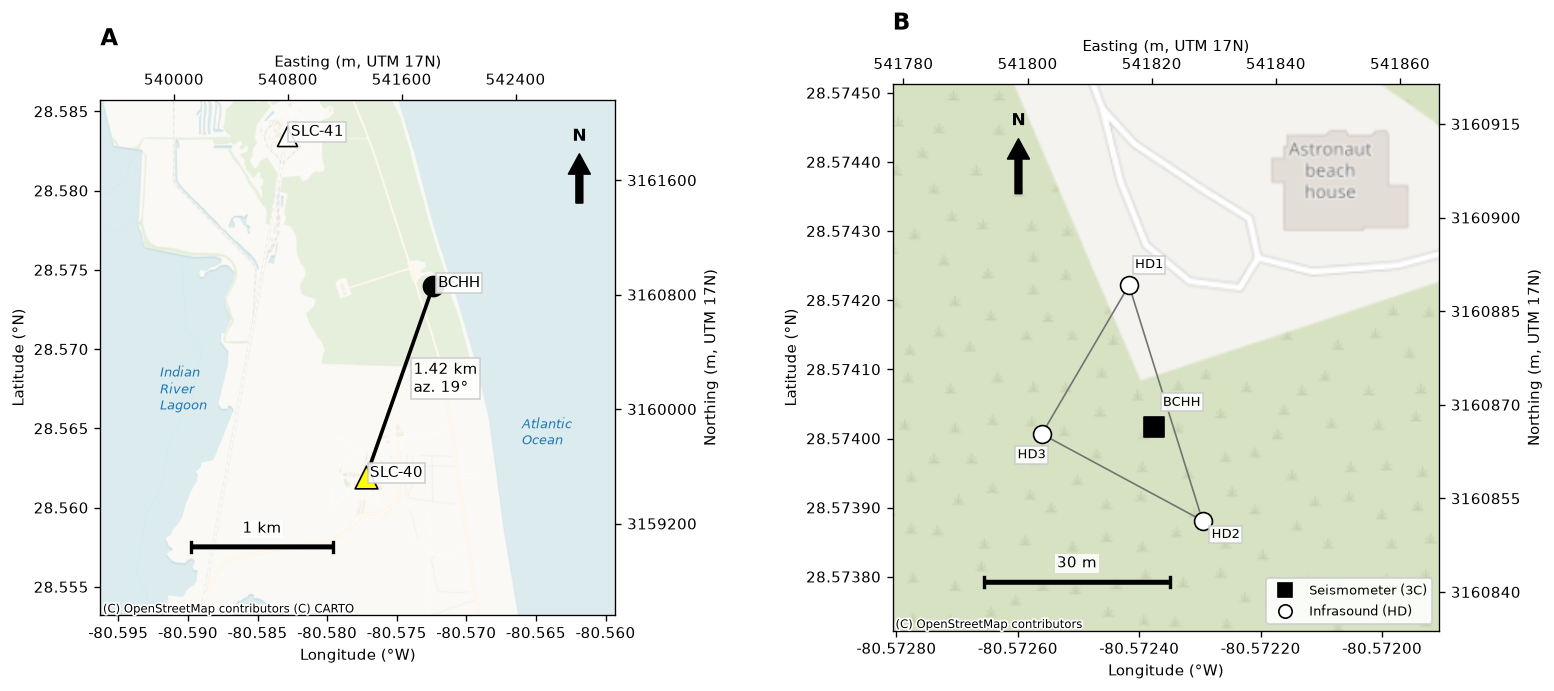

In [28]:
inventory_event, channels_df, stations_df, locations_df = read_geometry_products(DERIVED_DIR)

channel_to_sensor = {
    "DHZ": "Seismometer", "DHN": "Seismometer", "DHE": "Seismometer",
    "HHZ": "Seismometer", "HHN": "Seismometer", "HHE": "Seismometer",
    "DD1": "HD1", "DD2": "HD2", "DD3": "HD3",
    "HD1": "HD1", "HD2": "HD2", "HD3": "HD3",
}
channel_to_label = {key: ("BCHH" if value == "Seismometer" else value)
                    for key, value in channel_to_sensor.items()}

channels_for_map = channels_df.copy()
codes = channels_for_map["channel"].astype(str).str.upper()
channels_for_map["sensor"] = codes.map(channel_to_sensor)
channels_for_map["label"] = codes.map(channel_to_label)
channels_for_map["lat"] = channels_for_map["latitude"].astype(float)
channels_for_map["lon"] = channels_for_map["longitude"].astype(float)

wgs84 = CRS.from_epsg(4326)
utm17n = CRS.from_epsg(32617)
ll_to_utm = Transformer.from_crs(wgs84, utm17n, always_xy=True)
utm_to_ll = Transformer.from_crs(utm17n, wgs84, always_xy=True)
east, north = ll_to_utm.transform(channels_for_map["lon"], channels_for_map["lat"])
channels_for_map["easting"] = east
channels_for_map["northing"] = north

mapped = channels_for_map.dropna(subset=["sensor"])
seismometer = mapped.loc[mapped["sensor"].eq("Seismometer")].iloc[[0]]
infrasound = (
    mapped.loc[mapped["sensor"].isin(["HD1", "HD2", "HD3"])]
    .sort_values("sensor").drop_duplicates("sensor")
)
bchh_sensors = pd.concat([seismometer, infrasound], ignore_index=True)

def kml_location(kml_id):
    matches = locations_df.loc[locations_df["kml_id"].astype(str).str.upper().eq(kml_id.upper())]
    if len(matches) != 1:
        raise ValueError(f"Expected one {kml_id}; found {len(matches)}")
    row = matches.iloc[0]
    lat_key = "lat" if "lat" in row.index else "latitude"
    lon_key = "lon" if "lon" in row.index else "longitude"
    return {**row.to_dict(), "name": str(row.get("name", kml_id)),
            "lat": float(row[lat_key]), "lon": float(row[lon_key])}

slc40 = kml_location("SLC40")
slc41 = kml_location("SLC41")
bchh = get_sensor_location(bchh_sensors, sensor_name="Seismometer", display_name="BCHH")
make_kwargs = dict(
    slc40=slc40, slc41=slc41, bchh=bchh, bchh_sensors=bchh_sensors,
    geod=Geod(ellps="WGS84"), ll_to_utm=ll_to_utm, utm_to_ll=utm_to_ll,
)
original_add_basemap = figure1_utils.add_basemap
if os.environ.get("OFFLINE_BASEMAP", "0") == "1":
    figure1_utils.add_basemap = lambda *args, **kwargs: None
try:
    fig, axes = make_figure1(**make_kwargs)
except Exception as exc:
    # Preserve a reproducible geometry figure on offline systems. The user can
    # rerun later with network access to restore the contextual map tiles.
    plt.close("all")
    print(f"Basemap unavailable ({exc}); drawing geometry without map tiles.")
    figure1_utils.add_basemap = lambda *args, **kwargs: None
    fig, axes = make_figure1(**make_kwargs)
finally:
    figure1_utils.add_basemap = original_add_basemap
save_main(fig, "fig01_slc40_bchh_geometry")
plt.show()


## 3. Figure 2 — Complete sequence and candidate-event chronology


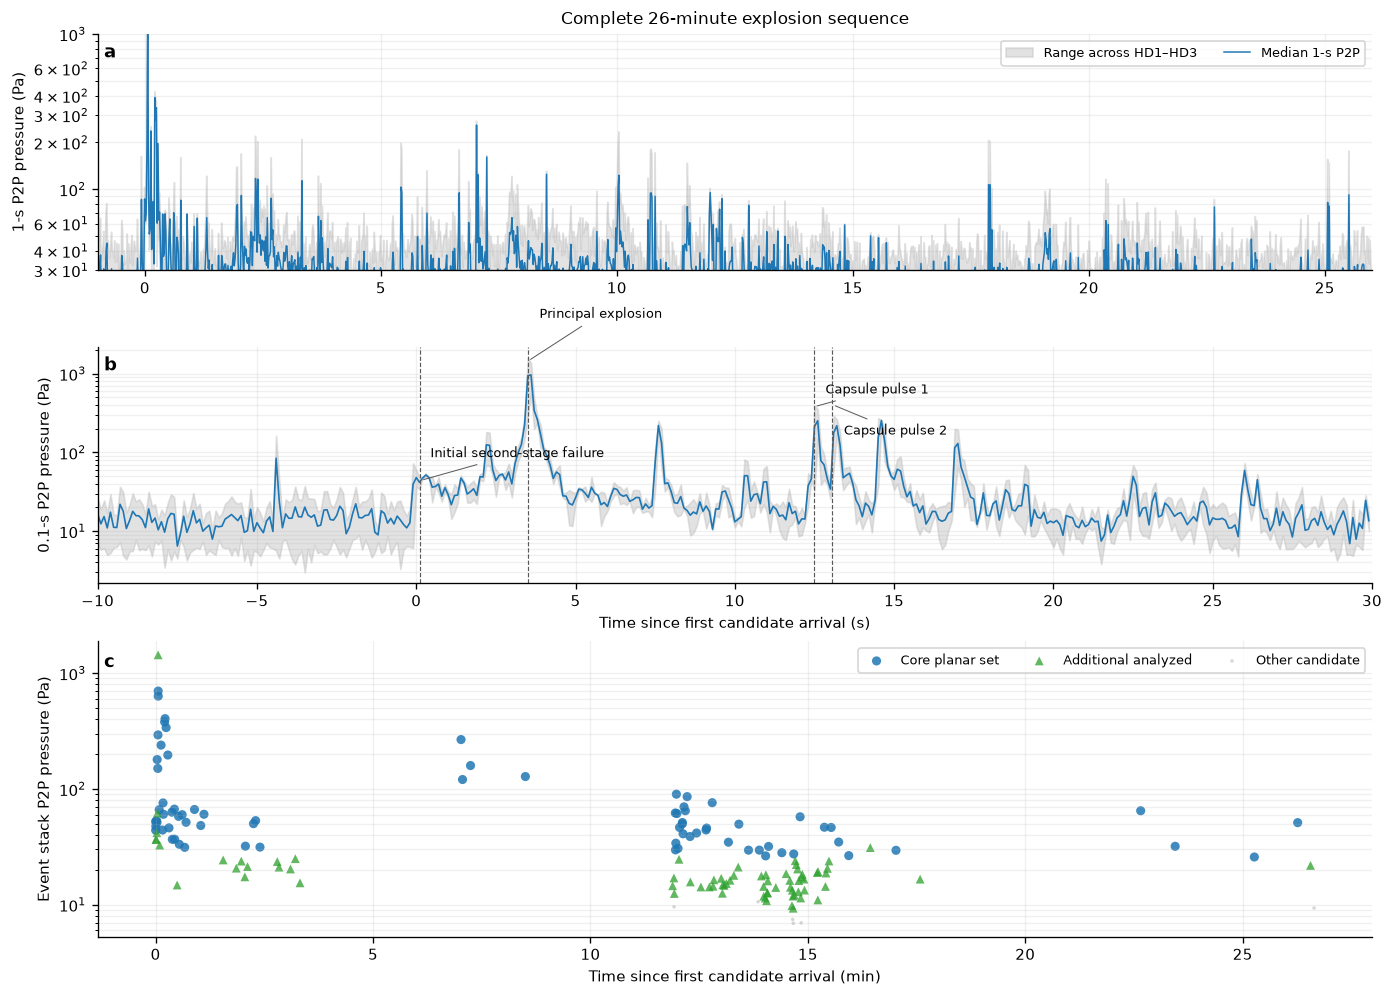

In [29]:
reference_epoch = float(measurements["reduced_event_epoch_s"].min())

def block_peak_to_peak(trace, window_s):
    """Return block-center times and peak-to-peak amplitudes without filtering."""
    data = np.asarray(trace.data, dtype=float)
    nper = max(2, int(round(window_s * trace.stats.sampling_rate)))
    nblock = data.size // nper
    blocks = data[:nblock * nper].reshape(nblock, nper)
    p2p = np.nanmax(blocks, axis=1) - np.nanmin(blocks, axis=1)
    centers = (
        float(trace.stats.starttime.timestamp)
        + (np.arange(nblock) * nper + 0.5 * (nper - 1)) / trace.stats.sampling_rate
    )
    return centers, p2p

def median_array_envelope(window_s):
    series = [block_peak_to_peak(st_baseline.select(channel=ch)[0], window_s)
              for ch in ("HD1", "HD2")]#, "HD3")]
    epoch = series[0][0]
    values = np.vstack([item[1] for item in series])
    return epoch, np.nanmedian(values, axis=0), np.nanmin(values, axis=0), np.nanmax(values, axis=0)

epoch_1s, median_1s, low_1s, high_1s = median_array_envelope(1.0)
epoch_100ms, median_100ms, low_100ms, high_100ms = median_array_envelope(0.10)

fig, axes = plt.subplots(3, 1, figsize=(11.5, 8.2), constrained_layout=True,
                         gridspec_kw={"height_ratios": [1.0, 1.0, 1.25]})

# (a) A readable whole-sequence envelope replaces the visually saturated raw traces.
xmin = (epoch_1s - reference_epoch) / 60.0
axes[0].fill_between(xmin, low_1s, high_1s, color="0.75", alpha=0.45,
                     label="Range across HD1–HD3")
axes[0].plot(xmin, median_1s, color="tab:blue", lw=0.9,
             label="Median 1-s P2P")
axes[0].set_yscale("log")
axes[0].set_xlim(0, float(measurements["elapsed_time_min"].max()))
axes[0].set_xlim(-1, 26)
axes[0].set_ylim(30,1000)
axes[0].set_ylabel("1-s P2P pressure (Pa)")
axes[0].set_title("Complete 26-minute explosion sequence")
axes[0].legend(loc="upper right", ncol=2, fontsize=8)

# (b) Expand the first 30 s so the principal and capsule-related stages separate.
xsec = epoch_100ms - reference_epoch
initial = (xsec >= -10) & (xsec <= 30)
axes[1].fill_between(xsec[initial], low_100ms[initial], high_100ms[initial],
                     color="0.75", alpha=0.45)
axes[1].plot(xsec[initial], median_100ms[initial], color="tab:blue", lw=1.0)
axes[1].set_yscale("log")
axes[1].set_xlim(-10, 30)
axes[1].set_ylabel("0.1-s P2P pressure (Pa)")
axes[1].set_xlabel("Time since first candidate arrival (s)")

label_offsets = {
    "second_stage": (6, 14), "principal_explosion": (7, 26),
    "capsule_pulse_1": (7, 8), "capsule_pulse_2": (7, -18),
}
for event_id, event_number in KEY_EVENT_NUMBERS.items():
    match = measurements.loc[measurements["event_number"].eq(event_number)]
    if match.empty:
        continue
    x_s = float(match.iloc[0]["reduced_event_epoch_s"] - reference_epoch)
    y = float(match.iloc[0]["acoustic_stack_peak_to_peak_pa"])
    axes[1].axvline(x_s, color="0.35", lw=0.7, ls="--")
    axes[1].annotate(KEY_EVENT_DISPLAY[event_id], xy=(x_s, y),
                     xytext=label_offsets[event_id], textcoords="offset points",
                     fontsize=8, arrowprops={"arrowstyle": "-", "lw": 0.6, "color": "0.35"})

# (c) Catalogue amplitudes show the discrete event chronology without raw-noise clutter.
for tier, style in TIER_STYLE.items():
    subset = measurements.loc[measurements["selection_tier"].eq(tier)]
    axes[2].scatter(subset["elapsed_time_min"], subset["acoustic_stack_peak_to_peak_pa"],
                    edgecolor="none", **style)
axes[2].set_yscale("log")
axes[2].set_xlabel("Time since first candidate arrival (min)")
axes[2].set_ylabel("Event stack P2P pressure (Pa)")
axes[2].legend(ncol=3, fontsize=8)

for label, ax in zip("abc", axes):
    ax.text(0.005, 0.96, label, transform=ax.transAxes, va="top", ha="left",
            fontsize=11, fontweight="bold")
    ax.grid(True, which="both", alpha=0.18)
save_main(fig, "fig02_complete_sequence_chronology")
plt.show()


## 4. Figure 3 — Key-event waveform montage


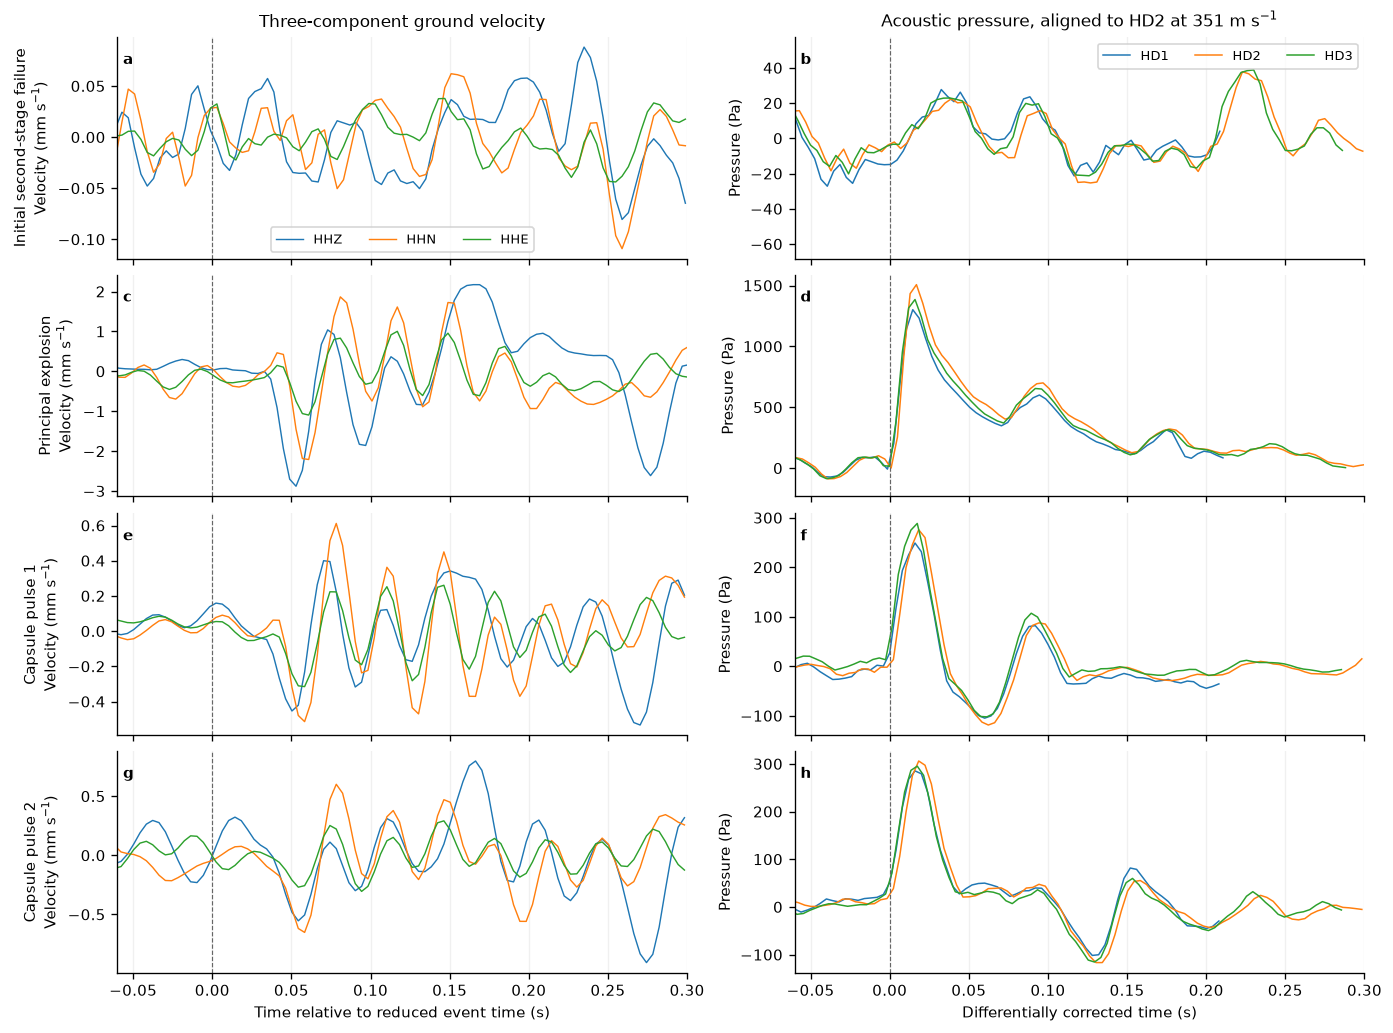

In [30]:
event_order = ["second_stage", "principal_explosion", "capsule_pulse_1", "capsule_pulse_2"]
fig, axes = plt.subplots(len(event_order), 2, figsize=(11.5, 8.5), sharex=True,
                         constrained_layout=True)

distance_by_channel = geometry.set_index("channel")["distance_m"].to_dict()
reference_distance_m = float(distance_by_channel["HD2"])
display_speed_mps = 351.0

for row_index, event_id in enumerate(event_order):
    event_number = KEY_EVENT_NUMBERS[event_id]
    event_row = candidates.loc[candidates["event_number"].eq(event_number)].iloc[0]
    stream_path = Path(event_row.get("segment_path", ""))
    if not stream_path.exists():
        stream_path = PREPARATION_ROOT / "event_streams" / f"candidate_event_{event_number:03d}.pkl"
    stream = read(str(stream_path), format="PICKLE")
    reference = UTCDateTime(float(event_row["reduced_event_epoch_s"]))

    ax_s, ax_a = axes[row_index]
    for channel in ("HHZ", "HHN", "HHE"):
        trace = stream.select(channel=channel)[0]
        # Millimetres per second avoid unreadable strings of leading zeros.
        ax_s.plot(trace.times(reftime=reference), np.asarray(trace.data) * 1e3,
                  lw=0.85, label=channel)
    for channel in ("HD1", "HD2", "HD3"):
        trace = stream.select(channel=channel)[0]
        differential_delay_s = (
            float(distance_by_channel[channel]) - reference_distance_m
        ) / display_speed_mps
        aligned_time = trace.times(reftime=reference) - differential_delay_s
        ax_a.plot(aligned_time, trace.data, lw=0.9, label=channel)

    ax_s.axvline(0, color="0.4", ls="--", lw=0.7)
    ax_a.axvline(0, color="0.4", ls="--", lw=0.7)
    ax_s.set_ylabel(f"{KEY_EVENT_DISPLAY[event_id]}\nVelocity (mm s$^{{-1}}$)")
    ax_a.set_ylabel("Pressure (Pa)")
    ax_s.set_xlim(-0.06, 0.30)
    ax_a.set_xlim(-0.06, 0.30)
    ax_s.grid(True, axis="x", alpha=0.18)
    ax_a.grid(True, axis="x", alpha=0.18)
    ax_s.text(0.01, 0.93, chr(ord("a") + 2 * row_index), transform=ax_s.transAxes,
              va="top", fontweight="bold")
    ax_a.text(0.01, 0.93, chr(ord("b") + 2 * row_index), transform=ax_a.transAxes,
              va="top", fontweight="bold")

axes[0, 0].set_title("Three-component ground velocity")
axes[0, 1].set_title("Acoustic pressure, aligned to HD2 at 351 m s$^{-1}$")
axes[0, 0].legend(ncol=3)
axes[0, 1].legend(ncol=3)
axes[-1, 0].set_xlabel("Time relative to reduced event time (s)")
axes[-1, 1].set_xlabel("Differentially corrected time (s)")
save_main(fig, "fig03_key_event_waveforms")
plt.show()


## 5. Figure 4 — Planar coherence and catalogue array results


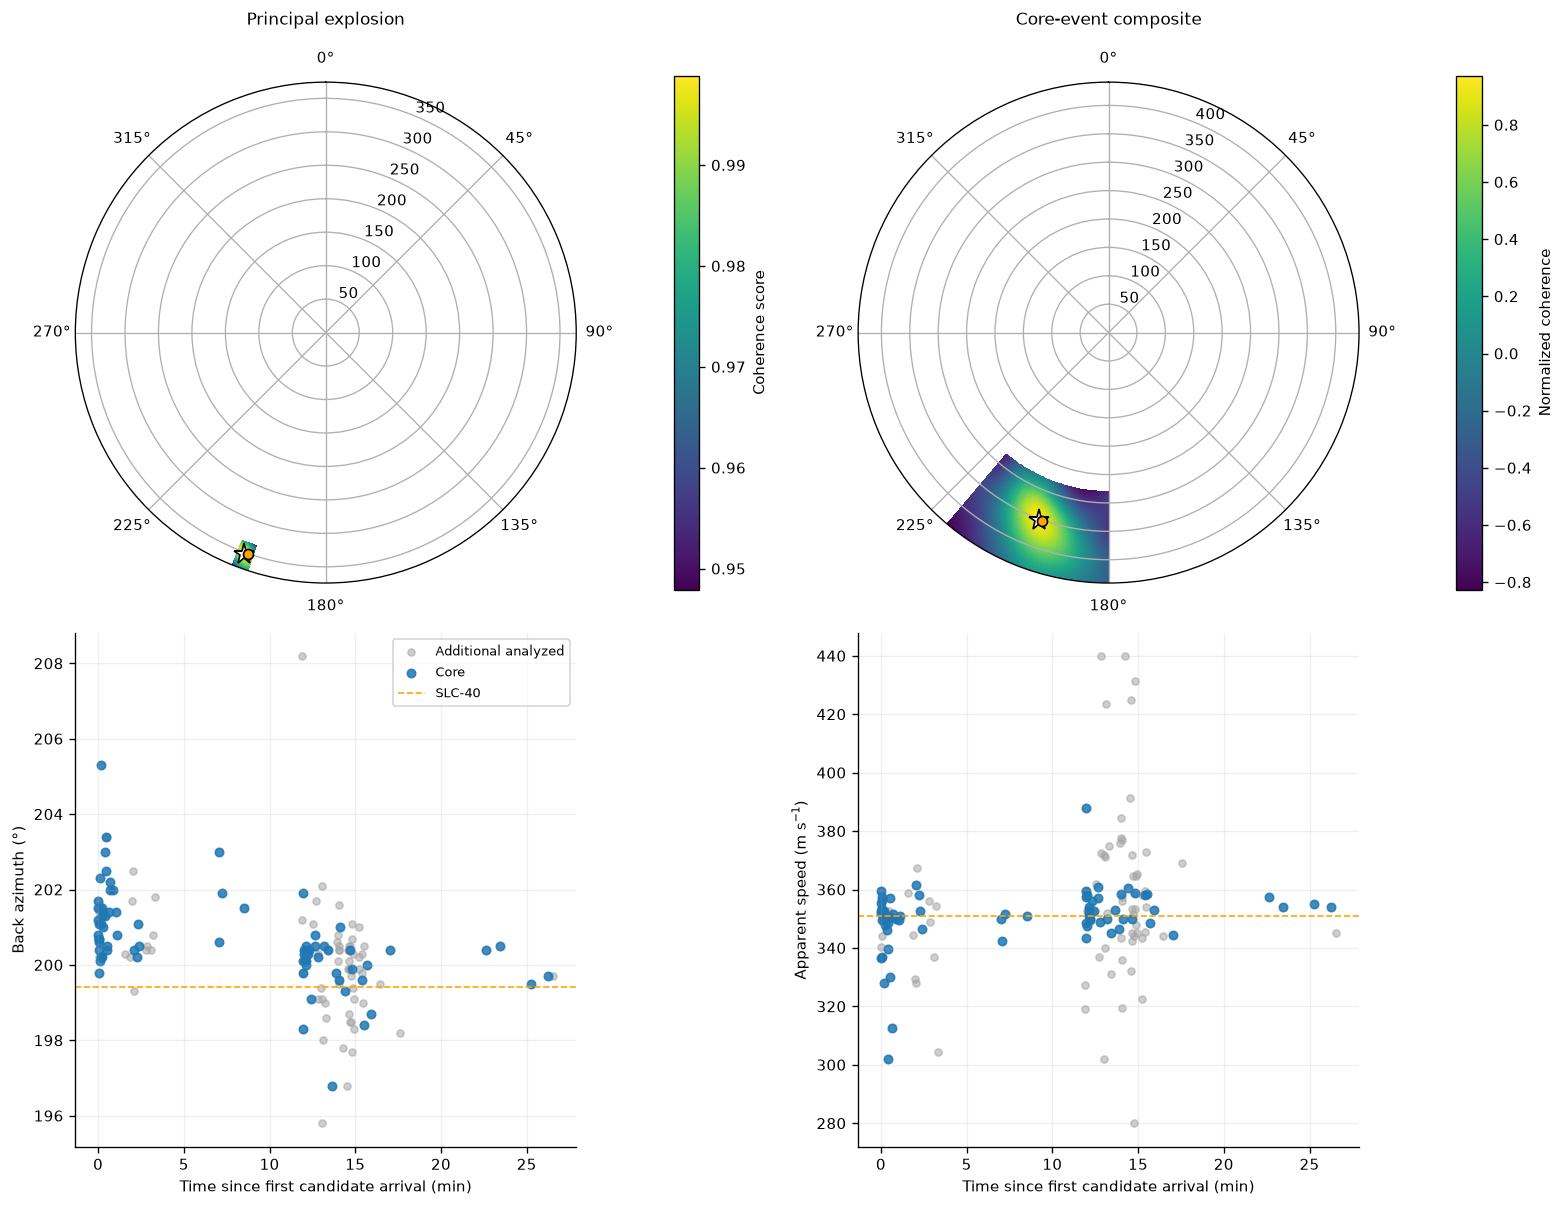

In [31]:
principal_surface = np.load(
    PLANAR_ROOT / "surfaces" / f"event_{PRINCIPAL_EVENT_NUMBER:03d}_planar_surface.npz"
)
composite = np.load(PLANAR_ROOT / "composites" / "composite_core_catalogue.npz")
expected_baz = float(analysis_config["array_reference"]["back_azimuth_to_slc40_deg"])
weather_speed = float(pd.read_csv(
    PROJECT_ROOT / "outputs" / "weather" / "derived" / "weather_acoustic_summary.csv"
).iloc[0]["effective_sound_speed_mps"])

fig = plt.figure(figsize=(13, 10), constrained_layout=True)
grid = fig.add_gridspec(2, 2)
ax0 = fig.add_subplot(grid[0, 0], projection="polar")
ax1 = fig.add_subplot(grid[0, 1], projection="polar")
ax2 = fig.add_subplot(grid[1, 0])
ax3 = fig.add_subplot(grid[1, 1])

def polar_surface(ax, azimuth, speed, score, title):
    mesh = ax.pcolormesh(np.deg2rad(azimuth), speed, score.T, shading="auto", cmap="viridis")
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    best = np.unravel_index(np.nanargmax(score), score.shape)
    ax.plot(np.deg2rad(azimuth[best[0]]), speed[best[1]], "*", ms=13,
            color="white", mec="black")
    ax.plot(np.deg2rad(expected_baz), weather_speed, "o", ms=6,
            color="orange", mec="black")
    ax.set_title(title, pad=16)
    return mesh

mesh0 = polar_surface(
    ax0, principal_surface["fine_back_azimuth_deg"],
    principal_surface["fine_apparent_speed_mps"],
    principal_surface["fine_coherence_score"], "Principal explosion",
)
mesh1 = polar_surface(
    ax1, composite["back_azimuth_deg"], composite["apparent_speed_mps"],
    composite["normalized_mean"], "Core-event composite",
)
fig.colorbar(mesh0, ax=ax0, pad=0.12, label="Coherence score")
fig.colorbar(mesh1, ax=ax1, pad=0.12, label="Normalized coherence")

planar_plot = planar.merge(
    measurements[["event_number", "elapsed_time_min"]], on="event_number", how="left"
)
core = planar_plot["passes_core_filter"].fillna(False).astype(bool)
ax2.scatter(planar_plot.loc[~core, "elapsed_time_min"], planar_plot.loc[~core, "best_back_azimuth_deg"],
            s=18, color="0.65", alpha=0.55, label="Additional analyzed")
ax2.scatter(planar_plot.loc[core, "elapsed_time_min"], planar_plot.loc[core, "best_back_azimuth_deg"],
            s=25, color="tab:blue", alpha=0.85, label="Core")
ax2.axhline(expected_baz, color="orange", ls="--", lw=1, label="SLC-40")
ax2.set_xlabel("Time since first candidate arrival (min)")
ax2.set_ylabel("Back azimuth (°)")
ax2.grid(True, alpha=0.2)
ax2.legend()

ax3.scatter(planar_plot.loc[~core, "elapsed_time_min"], planar_plot.loc[~core, "best_apparent_speed_mps"],
            s=18, color="0.65", alpha=0.55)
ax3.scatter(planar_plot.loc[core, "elapsed_time_min"], planar_plot.loc[core, "best_apparent_speed_mps"],
            s=25, color="tab:blue", alpha=0.85)
ax3.axhline(weather_speed, color="orange", ls="--", lw=1)
ax3.set_xlabel("Time since first candidate arrival (min)")
ax3.set_ylabel("Apparent speed (m s$^{-1}$)")
ax3.grid(True, alpha=0.2)

save_main(fig, "fig04_planar_array_results")
plt.show()


## 6. Figure 5 — Acoustic and seismic amplitudes through time


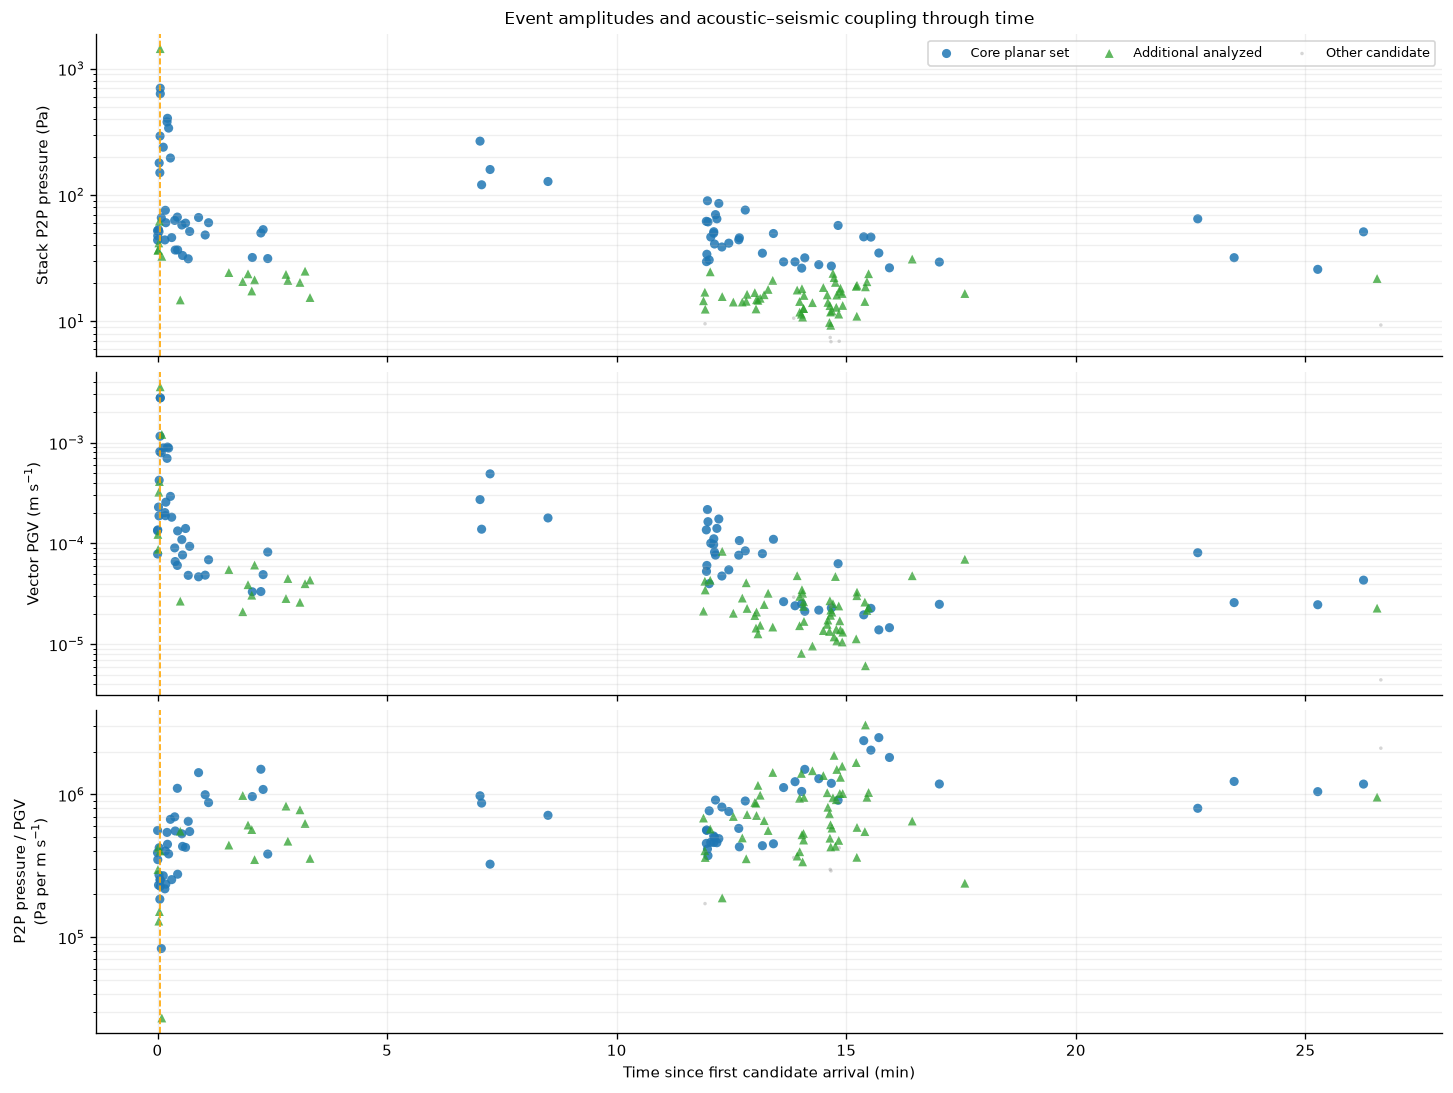

In [32]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True, constrained_layout=True)
columns = [
    ("acoustic_stack_peak_to_peak_pa", "Stack P2P pressure (Pa)"),
    ("pgv_vector_mps", "Vector PGV (m s$^{-1}$)"),
    ("p2p_pressure_to_vector_pgv", "P2P pressure / PGV\n(Pa per m s$^{-1}$)"),
]
for ax, (column, label) in zip(axes, columns):
    for tier, style in TIER_STYLE.items():
        subset = measurements.loc[measurements["selection_tier"].eq(tier)]
        ax.scatter(subset["elapsed_time_min"], subset[column], edgecolor="none", **style)
    ax.set_yscale("log")
    ax.set_ylabel(label)
    ax.grid(True, which="both", alpha=0.2)
principal = measurements.loc[measurements["event_number"].eq(PRINCIPAL_EVENT_NUMBER)].iloc[0]
for ax in axes:
    ax.axvline(principal["elapsed_time_min"], color="orange", ls="--", lw=1)
axes[0].set_title("Event amplitudes and acoustic–seismic coupling through time")
axes[0].legend(ncol=3)
axes[-1].set_xlabel("Time since first candidate arrival (min)")
save_main(fig, "fig05_amplitudes_and_coupling_vs_time")
plt.show()


## 7. Figure 6 — Acoustic pressure versus vector PGV


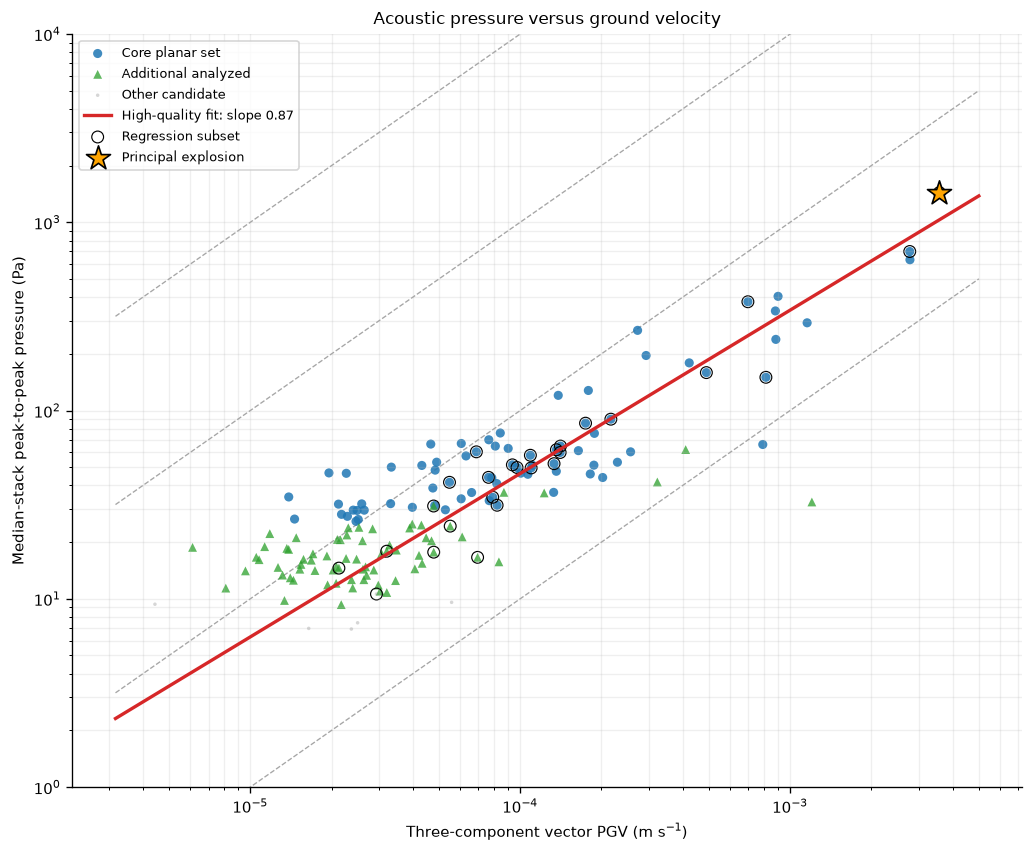

In [33]:
valid = measurements.loc[
    np.isfinite(measurements["acoustic_stack_peak_to_peak_pa"])
    & (measurements["acoustic_stack_peak_to_peak_pa"] > 0)
    & np.isfinite(measurements["pgv_vector_mps"])
    & (measurements["pgv_vector_mps"] > 0)
].copy()

fig, ax = plt.subplots(figsize=(8.5, 7), constrained_layout=True)
for tier, style in TIER_STYLE.items():
    subset = valid.loc[valid["selection_tier"].eq(tier)]
    ax.scatter(subset["pgv_vector_mps"], subset["acoustic_stack_peak_to_peak_pa"],
               edgecolor="none", **style)

xline = np.logspace(np.log10(valid["pgv_vector_mps"].min() / 1.4),
                    np.log10(valid["pgv_vector_mps"].max() * 1.4), 300)
for ratio in (1e5, 1e6, 1e7, 1e8):
    ax.plot(xline, ratio * xline, color="0.65", lw=0.8, ls="--", zorder=0)

quality = valid.loc[valid["passes_regression_quality"].fillna(False).astype(bool)]
if len(quality) >= 3:
    fit = linregress(np.log10(quality["pgv_vector_mps"]),
                     np.log10(quality["acoustic_stack_peak_to_peak_pa"]))
    ax.plot(xline, 10 ** (fit.intercept + fit.slope * np.log10(xline)),
            color="tab:red", lw=2, label=f"High-quality fit: slope {fit.slope:.2f}")
    ax.scatter(quality["pgv_vector_mps"], quality["acoustic_stack_peak_to_peak_pa"],
               facecolor="none", edgecolor="black", s=50, lw=0.7,
               label="Regression subset")

principal = valid.loc[valid["event_number"].eq(PRINCIPAL_EVENT_NUMBER)].iloc[0]
ax.scatter(principal["pgv_vector_mps"], principal["acoustic_stack_peak_to_peak_pa"],
           marker="*", s=230, facecolor="orange", edgecolor="black",
           zorder=6, label="Principal explosion")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim(1, 1e4)
ax.set_xlabel("Three-component vector PGV (m s$^{-1}$)")
ax.set_ylabel("Median-stack peak-to-peak pressure (Pa)")
ax.set_title("Acoustic pressure versus ground velocity")
ax.grid(True, which="both", alpha=0.2)
ax.legend()
save_main(fig, "fig06_pressure_vs_vector_pgv")
plt.show()


## 8. Supplementary Figure S1 — Spherical-wave constraints


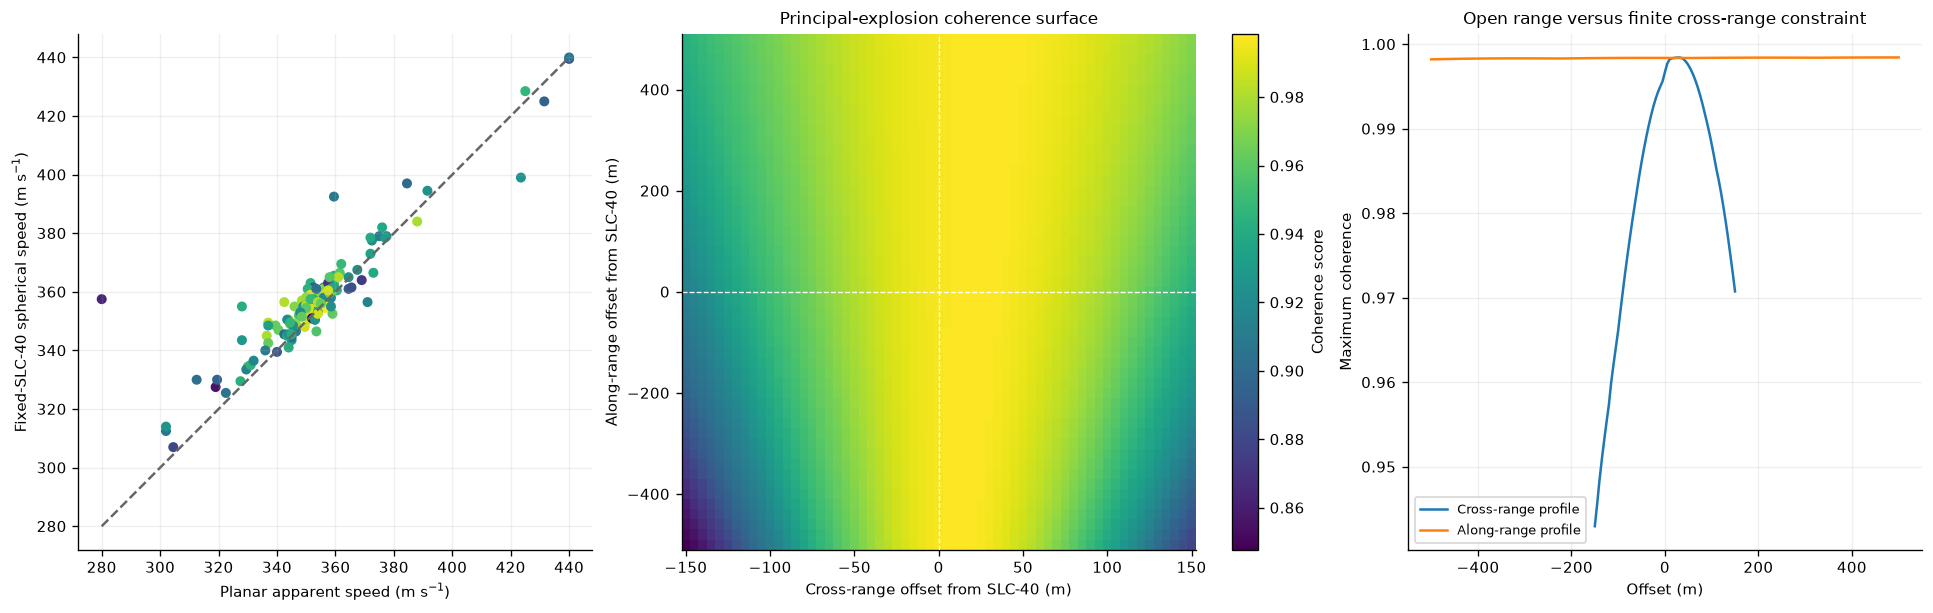

In [34]:
profile_npz = SPHERICAL_ROOT / "surfaces" / f"event_{PRINCIPAL_EVENT_NUMBER:03d}_range_profiles.npz"
profile = np.load(profile_npz)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)
axes[0].scatter(spherical["planar_speed_mps"], spherical["fixed_source_speed_mps"],
                c=spherical["fixed_source_coherence_score"], cmap="viridis", s=25)
limits = [min(spherical["planar_speed_mps"].min(), spherical["fixed_source_speed_mps"].min()),
          max(spherical["planar_speed_mps"].max(), spherical["fixed_source_speed_mps"].max())]
axes[0].plot(limits, limits, color="0.4", ls="--")
axes[0].set_xlabel("Planar apparent speed (m s$^{-1}$)")
axes[0].set_ylabel("Fixed-SLC-40 spherical speed (m s$^{-1}$)")
axes[0].grid(True, alpha=0.2)

mesh = axes[1].pcolormesh(profile["cross_range_m"], profile["along_range_m"],
                          profile["event_speed_score"], shading="auto", cmap="viridis")
axes[1].axhline(0, color="white", lw=0.8, ls="--")
axes[1].axvline(0, color="white", lw=0.8, ls="--")
axes[1].set_xlabel("Cross-range offset from SLC-40 (m)")
axes[1].set_ylabel("Along-range offset from SLC-40 (m)")
axes[1].set_title("Principal-explosion coherence surface")
fig.colorbar(mesh, ax=axes[1], label="Coherence score")

axes[2].plot(profile["cross_range_m"], profile["cross_profile_event_speed"],
             label="Cross-range profile")
axes[2].plot(profile["along_range_m"], profile["along_profile_event_speed"],
             label="Along-range profile")
axes[2].set_xlabel("Offset (m)")
axes[2].set_ylabel("Maximum coherence")
axes[2].set_title("Open range versus finite cross-range constraint")
axes[2].grid(True, alpha=0.2)
axes[2].legend()
save_supplement(fig, "figS01_spherical_constraints")
plt.show()


## 9. Table 1 — Instrumentation and calibration


In [35]:
table1 = pd.DataFrame([
    {"Instrument": "Nanometrics Trillium Compact Posthole", "Channels": "HHZ, HHN, HHE",
     "Sampling rate (Hz)": 250, "Calibration": "3.02 × 10^8 counts (m s^-1)^-1"},
    {"Instrument": "infraBSU", "Channels": "HD1", "Sampling rate (Hz)": 250,
     "Calibration": "8.10 counts Pa^-1"},
    {"Instrument": "infraBSU", "Channels": "HD2", "Sampling rate (Hz)": 250,
     "Calibration": "0.690 counts Pa^-1"},
    {"Instrument": "infraBSU", "Channels": "HD3", "Sampling rate (Hz)": 250,
     "Calibration": "10.0 counts Pa^-1"},
])
table1.to_csv(TABLE_DIR / "table01_instrumentation_calibration.csv", index=False)
(TABLE_DIR / "table01_instrumentation_calibration.tex").write_text(
    table1.to_latex(index=False, escape=False)
)
display(table1)


,Instrument,Channels,Sampling rate (Hz),Calibration
0,Nanometrics Trillium Compact Posthole,"HHZ, HHN, HHE",250,3.02 × 10^8 counts (m s^-1)^-1
1,infraBSU,HD1,250,8.10 counts Pa^-1
2,infraBSU,HD2,250,0.690 counts Pa^-1
3,infraBSU,HD3,250,10.0 counts Pa^-1


## 10. Table 2 — Key stages of the accident


In [36]:
key_rows = []
for event in key_events.itertuples(index=False):
    event_number = KEY_EVENT_NUMBERS[event.event_id]
    amplitude = measurements.loc[measurements["event_number"].eq(event_number)].iloc[0]
    array_match = planar.loc[planar["event_number"].eq(event_number)]
    array_row = array_match.iloc[0] if not array_match.empty else None
    source_distance = float(analysis_config["array_reference"]["distance_m"])
    key_rows.append({
        "Stage": KEY_EVENT_DISPLAY[event.event_id],
        "Candidate event": event_number,
        "Source time (UTC)": event.source_time,
        "Positive pressure (Pa)": amplitude["acoustic_stack_positive_peak_pa"],
        "Negative pressure (Pa)": amplitude["acoustic_stack_negative_peak_pa"],
        "Peak-to-peak pressure (Pa)": amplitude["acoustic_stack_peak_to_peak_pa"],
        "Reduced positive pressure at 1 km (Pa)": (
            amplitude["acoustic_stack_positive_peak_pa"] * source_distance / 1000.0
        ),
        "Vector PGV (m s^-1)": amplitude["pgv_vector_mps"],
        "Back azimuth (deg)": np.nan if array_row is None else array_row["best_back_azimuth_deg"],
        "Planar apparent speed (m s^-1)": np.nan if array_row is None else array_row["best_apparent_speed_mps"],
    })
table2 = pd.DataFrame(key_rows)
# Round at the precision justified by calibration, sampling, and grid spacing.
table2["Source time (UTC)"] = pd.to_datetime(table2["Source time (UTC)"], utc=True).dt.strftime(
    "%Y-%m-%dT%H:%M:%S.%fZ"
).str[:-4] + "Z"
for column in ("Positive pressure (Pa)", "Negative pressure (Pa)",
               "Peak-to-peak pressure (Pa)",
               "Reduced positive pressure at 1 km (Pa)"):
    table2[column] = table2[column].round(0).astype("Int64")
table2["Vector PGV (m s^-1)"] = table2["Vector PGV (m s^-1)"].map(
    lambda value: float(f"{value:.3g}")
)
table2["Back azimuth (deg)"] = table2["Back azimuth (deg)"].round(1)
table2["Planar apparent speed (m s^-1)"] = table2[
    "Planar apparent speed (m s^-1)"
].round(1)
table2.to_csv(TABLE_DIR / "table02_key_accident_stages.csv", index=False)
(TABLE_DIR / "table02_key_accident_stages.tex").write_text(table2.to_latex(index=False))
display(table2)


,Stage,Candidate event,Source time (UTC),Positive pressure (Pa),Negative pressure (Pa),Peak-to-peak pressure (Pa),Reduced positive pressure at 1 km (Pa),Vector PGV (m s^-1),Back azimuth (deg),Planar apparent speed (m s^-1)
0,Initial second-stage failure,2,2016-09-01T13:07:12.080Z,23,-21,44,32,0.000078,201.5,355.5
1,Principal explosion,13,2016-09-01T13:07:15.750Z,1353,-84,1437,1919,0.003570,200.2,352.5
2,Capsule pulse 1,22,2016-09-01T13:07:24.600Z,276,-102,378,391,0.000698,201.5,351.5
3,Capsule pulse 2,23,2016-09-01T13:07:25.150Z,291,-113,404,413,0.000902,201.3,351.0


## 11. Table 3 — Principal explosion summary


In [37]:
principal_amp = measurements.loc[
    measurements["event_number"].eq(PRINCIPAL_EVENT_NUMBER)
].iloc[0]
principal_planar = planar.loc[planar["event_number"].eq(PRINCIPAL_EVENT_NUMBER)].iloc[0]
principal_spherical = spherical.loc[
    spherical["event_number"].eq(PRINCIPAL_EVENT_NUMBER)
].iloc[0]
principal_source_time = key_events.loc[
    key_events["event_id"].eq("principal_explosion"), "source_time"
].iloc[0]
reference_distance = float(analysis_config["array_reference"]["distance_m"])
positive_pressure = float(principal_amp["acoustic_stack_positive_peak_pa"])

principal_values = [
    ("Estimated source time", principal_source_time, "UTC"),
    ("Positive pressure", positive_pressure, "Pa"),
    ("Negative pressure", principal_amp["acoustic_stack_negative_peak_pa"], "Pa"),
    ("Peak-to-peak pressure", principal_amp["acoustic_stack_peak_to_peak_pa"], "Pa"),
    ("Reduced positive pressure", positive_pressure * reference_distance / 1000.0, "Pa at 1 km"),
    ("Peak sound-pressure level", 20 * np.log10(positive_pressure / 20e-6), "dB re 20 µPa"),
    ("Three-component vector PGV", principal_amp["pgv_vector_mps"], "m s^-1"),
    ("Planar back azimuth", principal_planar["best_back_azimuth_deg"], "deg"),
    ("Planar apparent speed", principal_planar["best_apparent_speed_mps"], "m s^-1"),
    ("Planar coherence score", principal_planar["maximum_coherence_score"], "dimensionless"),
    ("Fixed-SLC-40 spherical speed", principal_spherical["fixed_source_speed_mps"], "m s^-1"),
]

energy_file = DERIVED_DIR / "principal_explosion_energy_summary.csv"
if energy_file.exists():
    energy = pd.read_csv(energy_file).iloc[0]
    optional = [
        ("Acoustic energy", energy.get("acoustic_energy_j", np.nan), "J"),
        ("Seismic energy", energy.get("seismic_energy_j", np.nan), "J"),
        ("Equivalent acoustic magnitude", energy.get("acoustic_magnitude", np.nan), ""),
        ("Equivalent seismic magnitude", energy.get("seismic_magnitude", np.nan), ""),
    ]
    principal_values.extend(optional)
else:
    print("Energy rows omitted: principal_explosion_energy_summary.csv is not yet available.")

table3 = pd.DataFrame(principal_values, columns=["Parameter", "Value", "Units"])
def format_principal_value(row):
    parameter, value = row["Parameter"], row["Value"]
    if parameter == "Estimated source time":
        return pd.to_datetime(value, utc=True).strftime("%Y-%m-%dT%H:%M:%S.%f")[:-3] + "Z"
    value = float(value)
    if "pressure" in parameter.lower() and "level" not in parameter.lower():
        return f"{value:.0f}"
    if parameter == "Peak sound-pressure level":
        return f"{value:.1f}"
    if parameter == "Three-component vector PGV":
        return f"{value:.3g}"
    if parameter in {"Planar back azimuth", "Planar apparent speed",
                     "Fixed-SLC-40 spherical speed"}:
        return f"{value:.1f}"
    if parameter == "Planar coherence score":
        return f"{value:.3f}"
    if "energy" in parameter.lower():
        return f"{value:.3g}"
    return f"{value:.2f}"

table3["Value"] = table3.apply(format_principal_value, axis=1)
table3.to_csv(TABLE_DIR / "table03_principal_explosion_summary.csv", index=False)
(TABLE_DIR / "table03_principal_explosion_summary.tex").write_text(
    table3.to_latex(index=False, escape=False)
)
display(table3)


Energy rows omitted: principal_explosion_energy_summary.csv is not yet available.


,Parameter,Value,Units
0,Estimated source time,2016-09-01T13:07:15.750Z,UTC
1,Positive pressure,1353,Pa
2,Negative pressure,-84,Pa
3,Peak-to-peak pressure,1437,Pa
4,Reduced positive pressure,1919,Pa at 1 km
5,Peak sound-pressure level,156.6,dB re 20 µPa
6,Three-component vector PGV,0.00357,m s^-1
7,Planar back azimuth,200.2,deg
8,Planar apparent speed,352.5,m s^-1
9,Planar coherence score,0.999,dimensionless


## 12. Table 4 — Catalogue and array-analysis summary


In [38]:
core_planar = planar.loc[planar["passes_core_filter"].fillna(False).astype(bool)]
summary_rows = [
    ("Multi-channel candidate events", len(candidates), "count"),
    ("Events passing permissive planar filter", int(decisions["passes_analysis_filter"].sum()), "count"),
    ("Core planar events", int(decisions["passes_core_filter"].sum()), "count"),
    ("Median planar back azimuth", planar["best_back_azimuth_deg"].median(), "deg"),
    ("Planar back-azimuth IQR", planar["best_back_azimuth_deg"].quantile(.75) - planar["best_back_azimuth_deg"].quantile(.25), "deg"),
    ("Median planar apparent speed", planar["best_apparent_speed_mps"].median(), "m s^-1"),
    ("Planar apparent-speed IQR", planar["best_apparent_speed_mps"].quantile(.75) - planar["best_apparent_speed_mps"].quantile(.25), "m s^-1"),
    ("Median planar coherence", planar["maximum_coherence_score"].median(), "dimensionless"),
    ("Median fixed-source spherical speed", spherical["fixed_source_speed_mps"].median(), "m s^-1"),
    ("Events in high-quality coupling regression", int(measurements["passes_regression_quality"].sum()), "count"),
]
table4 = pd.DataFrame(summary_rows, columns=["Quantity", "Value", "Units"])
def format_summary_value(row):
    value = float(row["Value"])
    if row["Units"] == "count":
        return f"{int(round(value))}"
    if row["Units"] in {"deg", "m s^-1"}:
        return f"{value:.1f}"
    if row["Units"] == "dimensionless":
        return f"{value:.3f}"
    return f"{value:.3g}"

table4["Value"] = table4.apply(format_summary_value, axis=1)
table4.to_csv(TABLE_DIR / "table04_catalogue_array_summary.csv", index=False)
(TABLE_DIR / "table04_catalogue_array_summary.tex").write_text(
    table4.to_latex(index=False, escape=False)
)
display(table4)


,Quantity,Value,Units
0,Multi-channel candidate events,154,count
1,Events passing permissive planar filter,148,count
2,Core planar events,76,count
3,Median planar back azimuth,200.4,deg
4,Planar back-azimuth IQR,1.3,deg
5,Median planar apparent speed,352.0,m s^-1
6,Planar apparent-speed IQR,12.6,m s^-1
7,Median planar coherence,0.819,dimensionless
8,Median fixed-source spherical speed,355.8,m s^-1
9,Events in high-quality coupling regression,27,count


## 13. Supplementary catalogue tables and product manifest


In [39]:
supplement_catalogue = (
    measurements.merge(
        planar[[c for c in planar.columns if c != "stream_file"]],
        on="event_number", how="left", suffixes=("", "_planar"),
    )
    .merge(
        spherical[["event_number", "fixed_source_speed_mps",
                   "fixed_source_coherence_score"]],
        on="event_number", how="left",
    )
)
supplement_catalogue.to_csv(TABLE_DIR / "tableS01_full_event_catalogue.csv", index=False)
geometry.to_csv(TABLE_DIR / "tableS02_receiver_geometry.csv", index=False)

manifest = {
    "main_figures": sorted(path.name for path in MAIN_FIGURE_DIR.glob("*")),
    "supplementary_figures": sorted(path.name for path in SUPPLEMENT_FIGURE_DIR.glob("*")),
    "tables": sorted(path.name for path in TABLE_DIR.glob("*")),
    "source_notebooks": list(range(1, 9)),
    "warning": "Rerun Notebooks 01–08 before freezing manuscript values.",
}
(PRODUCT_ROOT / "paper_product_manifest.json").write_text(json.dumps(manifest, indent=2) + "\n")
display(pd.Series({key: len(value) if isinstance(value, list) else value
                   for key, value in manifest.items()}, name="value").to_frame())
print("Main figures:", MAIN_FIGURE_DIR)
print("Supplementary figures:", SUPPLEMENT_FIGURE_DIR)
print("Tables:", TABLE_DIR)


,value
main_figures,16
supplementary_figures,10
tables,11
source_notebooks,8
warning,Rerun Notebooks 01–08 before freezing manuscri...


Main figures: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/outputs/paper_products/main_figures
Supplementary figures: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/outputs/paper_products/supplementary_figures
Tables: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/outputs/paper_products/tables
